# 📚 Pipeline Analítico de Séries Temporais em Deep Learning (LSTM)

**Projeto:** Análise e Predição de Alarmes (`Is_Dont_Go`)
**Fase:** Modelagem Preditiva Sequencial e Recorrente

> 💡 **Objetivo Principal:** Diferente dos métodos estáticos, a **LSTM (Long Short-Term Memory)** tenta "lembrar" o fluxo dos acontecimentos. Um alarme grave hoje pode estar ligado ao histórico contínuo da máquina nas últimas 24 horas. Este notebook visa prever cenários de falha iminente utilizando redes neurais profundas.

## 🔍 1. Configuração do Ambiente e Bibliotecas

Importação de pacotes necessários para manipulação algébrica (`numpy`, `pandas`), visualização (`matplotlib`, `seaborn`) e ferramentas do `scikit-learn` para escalonamento e codificação.

In [112]:
import os
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Lambda, Embedding, Concatenate, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# ---------------------------------------------------------
# CONFIGURAÇÃO DE REPRODUTIBILIDADE (SEED GLOBAL)
# ---------------------------------------------------------
def set_global_seed(seed_value=42):
    # 1. Travar as variáveis de ambiente de Hash do Python
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    
    # 2. Travar o gerador nativo do Python
    random.seed(seed_value)
    
    # 3. Travar o gerador do Numpy (usado no undersampling e divisões)
    np.random.seed(seed_value)
    
    # 4. Travar os pesos e inicializações do Keras/TensorFlow
    tf.random.set_seed(seed_value)
    
    # Opcional: Para forçar operações determinísticas extremas na GPU (apenas em TF >= 2.8)
    tf.config.experimental.enable_op_determinism()

# Inicializa a semente
set_global_seed(42)
print("Seed global (42) configurada com sucesso para Python, NumPy e TensorFlow!")

Seed global (42) configurada com sucesso para Python, NumPy e TensorFlow!


## 🔍 2. Auditoria e Liberação de Recursos Computacionais (GPU/CPU)

Certificando-se de que o sistema TensorFlow está corretamente ligado ao hardware GPU se disponível (via CUDA). Treinar LSTMs em bases muito longas consome muita demanda matricial.

In [113]:
# Verifica quais dispositivos estão disponíveis
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU detectada! O modelo vai voar 🚀: {gpus}")
else:
    print("Ainda usando CPU 🐢. Verifique a configuração do ambiente.")

GPU detectada! O modelo vai voar 🚀: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 🔍 3. Divisão de Dados Estritamente Sequencial

Em séries temporais não podemos usar o clássico reparticionamento aleatório do Scikit-Learn. Prever o passado baseando-se no futuro seria um grave **Vazamento de Dados (Data Leakage)**.

> ⚠️ **Abordagem Empregada:** Quebramos a matriz da esquerda para a direita no eixo do tempo de forma linear, garantindo que o dataset de teste só avalie cenários temporais estritos do 'futuro' em relação ao lote de treino.

In [114]:
months = ["jan", "feb", "marco", "apr", "may", "jun"]
mes_escolhido = "jun"  # Ajuste conforme o mês desejado

# Lendo de notebooks/jun/jun_dados_lstm.csv
caminho_entrada = os.path.join(".", mes_escolhido, f"{mes_escolhido}_dados_lstm.csv")
df = pd.read_csv(caminho_entrada)

In [115]:


# --- PREVENÇÃO DE DATA LEAKAGE ---
cols_features = [
    'Tag_Frota', 'Tipo', 'Matricula_Operador_Hash', 'Id_Alarme', 'Id_Criticidade', 
    'Valor', 'Tempo_Trabalhando_Horas', 'Periodo_Dia_Int', 
    'Dia_1', 'Dia_2', 'Dia_3', 'Dia_4', 'Dia_5', 'Dia_6'
]

# ---------------------------------------------------------
# INÍCIO DA PARTE QUE ESTAVA FALTANDO (SPLIT CRONOLÓGICO)
# ---------------------------------------------------------
print("Realizando a divisão cronológica (80% Treino, 20% Teste)...")

# Em séries temporais, não podemos usar o train_test_split aleatório do sklearn.
# Precisamos garantir que os dados estejam ordenados pelo tempo.
# Se o seu CSV tiver uma coluna de Data/Hora, certifique-se de ordenar antes (ex: df = df.sort_values('Data_Hora'))

tamanho_treino = int(len(df) * 0.80)

# Divide sequencialmente
df_train = df.iloc[:tamanho_treino].copy()
df_test = df.iloc[tamanho_treino:].copy()

print(f"Tamanho do Treino: {len(df_train)} linhas")
print(f"Tamanho do Teste: {len(df_test)} linhas")
# ---------------------------------------------------------

# 3. Padronização 
print("Aplicando StandardScaler (Fit no Treino, Transform no Teste)...")
scaler = StandardScaler()
cols_to_scale = ['Valor', 'Tempo_Trabalhando_Horas']

df_train.loc[:, cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])
df_test.loc[:, cols_to_scale] = scaler.transform(df_test[cols_to_scale])
# 4. Configurações da Janela Temporal
SEQ_LENGTH = 30
PROBABILIDADE_MANTER_ZERO = 0.30

Realizando a divisão cronológica (80% Treino, 20% Teste)...
Tamanho do Treino: 100745 linhas
Tamanho do Teste: 25187 linhas
Aplicando StandardScaler (Fit no Treino, Transform no Teste)...


## 🔍 4. Mapeamento de Categóricos (Label Encoding Residual)

Preparação matemática e normalização de variáveis simbólicas não contínuas, moldando os IDs categóricos longos em faixas menores permitidas e mapeadas nas Camadas Embutidas de Embeddings.

In [116]:
from sklearn.preprocessing import LabelEncoder

print("Aplicando Label Encoding para variáveis categóricas de alta cardinalidade...")

# 1. Transforma os IDs gigantes em números sequenciais (0 até N)
le_operador = LabelEncoder()
df['Matricula_Operador_Hash'] = le_operador.fit_transform(df['Matricula_Operador_Hash'])

le_alarme = LabelEncoder()
df['Id_Alarme'] = le_alarme.fit_transform(df['Id_Alarme'])

# 2. Agora o tamanho do vocabulário é exatamente a quantidade de IDs ÚNICOS que existem, mais 1 (para segurança)
VOCAB_OPERADOR = df['Matricula_Operador_Hash'].nunique() + 1
VOCAB_ALARME = df['Id_Alarme'].nunique() + 1

print(f"Vocabulário de Operadores Corrigido: {VOCAB_OPERADOR}")
print(f"Vocabulário de Alarmes Corrigido: {VOCAB_ALARME}")


Aplicando Label Encoding para variáveis categóricas de alta cardinalidade...
Vocabulário de Operadores Corrigido: 316
Vocabulário de Alarmes Corrigido: 440


## 🔍 5. Montagem de Estruturas Tensoriais Multidimensionais

A LSTM não aceita dados bidimensionais convencionais (Linhas, Colunas). Ela precisa do vetor tempo.

### 🛠️ Entendendo a Forma do Tensor: `(Batch, Timesteps, Features)`
- Extraímos fragmentos (janelas limitadas). Cada bloco alimentado para a rede consiste em observar um número de amostras (batch), analisando os últimos `N` passos de tempo (timesteps), e utilizando um grande pool de variáveis simultâneas (features).

In [ ]:
def criar_tensores(df_subset, is_train=True):
    X_list, y_list = [], []
    
    # O loop groupby('TAG') garante isolamento. 
    # Sequências do Caminhão A NUNCA se misturarão com o Caminhão B.
    for tag, group in tqdm(df_subset.groupby('TAG'), desc=f"Gerando janelas ({'Treino' if is_train else 'Teste'})"):
        X_group = group[cols_features].values
        
        # --- ADAPTAÇÃO DO TARGET ---
        # Substituímos 'Is_Dont_Go' por 'Target_Predictive' (o target já adiantado 4h no Notebook 2)
        y_group = group['Target_Predictive'].values
        
        # Se um caminhão tem menos registros que o tamanho da janela, ele é ignorado
        if len(X_group) < SEQ_LENGTH:
            continue
            
        for i in range(len(X_group) - SEQ_LENGTH):
            target = y_group[i + SEQ_LENGTH - 1]
            
            # Sub-amostragem da classe majoritária APENAS no conjunto de treinamento
            if is_train and target == 0 and np.random.rand() > PROBABILIDADE_MANTER_ZERO:
                continue
                
            janela = X_group[i : i + SEQ_LENGTH]
            X_list.append(janela)
            y_list.append(target)
            
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int8)

# Gerando os Tensores Finais
print("\nGerando tensores de Treino...")
X_train, y_train = criar_tensores(df_train, is_train=True)

print("\nGerando tensores de Teste...")
X_test, y_test = criar_tensores(df_test, is_train=False)

print("\n--- RESUMO DOS TENSORES ---")
print(f"Treino X: {X_train.shape} | Y: {y_train.shape} | % Classe 1: {(y_train.mean()*100):.2f}%")
print(f"Teste  X: {X_test.shape}  | Y: {y_test.shape}  | % Classe 1: {(y_test.mean()*100):.2f}%")

# Salvando
# --- SALVAMENTO ESTRUTURADO DE TENSORES ---

# Define a pasta correta criando a subpasta do mês: ../resultados/jun/
pasta_resultados = os.path.join('..', 'resultados', mes_escolhido)
os.makedirs(pasta_resultados, exist_ok=True)

# Salva cada array diretamente dentro da subpasta do mês
np.save(os.path.join(pasta_resultados, f'{mes_escolhido}_X_train.npy'), X_train)
np.save(os.path.join(pasta_resultados, f'{mes_escolhido}_y_train.npy'), y_train)
np.save(os.path.join(pasta_resultados, f'{mes_escolhido}_X_test.npy'), X_test)
np.save(os.path.join(pasta_resultados, f'{mes_escolhido}_y_test.npy'), y_test)

print(f"✅ Tensores isolados e salvos com sucesso em: {pasta_resultados}/")


Gerando tensores de Treino...


Gerando janelas (Treino): 100%|██████████| 26/26 [00:00<00:00, 863.40it/s]



Gerando tensores de Teste...


Gerando janelas (Teste): 100%|██████████| 6/6 [00:00<00:00, 1064.54it/s]


--- RESUMO DOS TENSORES ---
Treino X: (36239, 30, 14) | Y: (36239,) | % Classe 1: 24.66%
Teste  X: (25007, 30, 14)  | Y: (25007,)  | % Classe 1: 1.10%
Tensores isolados e salvos com sucesso em ../resultados/jun/


## 🔍 6. Estruturação Arquitetural LSTM e Processo de Compilação

Montamos os blocos (Layers) profundos da Rede. Categóricos recebem uma transformação vetorial (Embedding), cruzando-se em seguida com os dados numéricos antes de entrar no complexo cérebro de recorrências da LSTM, que filtra a informação que deve ser "lembrada" e a que deve ser "esquecida". O aprendizado é medido utilizando perdas customizadas como a entropia binária.

In [118]:
VOCAB_OPERADOR = int(df['Matricula_Operador_Hash'].max()) + 1
VOCAB_ALARME = int(df['Id_Alarme'].max()) + 1

print(f"Vocabulário de Operadores: {VOCAB_OPERADOR}")
print(f"Vocabulário de Alarmes: {VOCAB_ALARME}")

# 2. Definição da Entrada
# Formato: (Passos no Tempo = 30, Atributos = 14)
input_layer = Input(shape=(SEQ_LENGTH, 14), name="Input_Completo")

# 1. Calculando pesos das classes para lidar com o desbalanceamento no treino
pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(pesos))
print(f"Pesos das Classes: {class_weights}")

# 2. Definição da Entrada
# Formato: (Passos no Tempo = 30, Atributos = 14)
input_layer = Input(shape=(SEQ_LENGTH, 14), name="Input_Completo")

# 3. Funções de Fatiamento (Slicing) para as camadas Lambda
# O índice das colunas segue a lista: 
# 2 = Matricula_Operador_Hash | 3 = Id_Alarme
def slice_operador(x): return x[:, :, 2]
def slice_alarme(x): return x[:, :, 3]

def slice_numericos_e_restante(x):
    # Pega índices 0, 1 (Tag, Tipo) e 4 a 13 (Id_Criticidade até Dia_6)
    part_1 = x[:, :, 0:2]
    part_2 = x[:, :, 4:14]
    return tf.concat([part_1, part_2], axis=-1)

# Aplicando as fatias
operador_input = Lambda(slice_operador, name="Slice_Operador")(input_layer)
alarme_input = Lambda(slice_alarme, name="Slice_Alarme")(input_layer)
numericos_input = Lambda(slice_numericos_e_restante, name="Slice_Numericos")(input_layer)

# 4. Camadas de Embedding (Ajuste o output_dim conforme sua necessidade)
EMB_DIM = 8 
emb_operador = Embedding(input_dim=VOCAB_OPERADOR, output_dim=EMB_DIM, name="Emb_Operador")(operador_input)
emb_alarme = Embedding(input_dim=VOCAB_ALARME, output_dim=EMB_DIM, name="Emb_Alarme")(alarme_input)

# 5. Concatenação de todas as features em cada passo de tempo
# As saídas do embedding terão shape (Batch, 30, 8), e a parte numérica (Batch, 30, 12)
concat_layer = Concatenate(axis=-1, name="Concat_Features")([numericos_input, emb_operador, emb_alarme])

# 6. Arquitetura LSTM Profunda
lstm_1 = LSTM(64, return_sequences=True, name="LSTM_1")(concat_layer)
bn_1 = BatchNormalization(name="BatchNorm_1")(lstm_1)
drop_1 = Dropout(0.3, name="Drop_1")(bn_1)

lstm_2 = LSTM(32, return_sequences=False, name="LSTM_2")(drop_1)
bn_2 = BatchNormalization(name="BatchNorm_2")(lstm_2)
drop_2 = Dropout(0.3, name="Drop_2")(bn_2)

# 7. Camada de Saída (Classificação Binária)
output_layer = Dense(1, activation='sigmoid', name="Saida_Classificacao")(drop_2)

# Construindo o Modelo
model = Model(inputs=input_layer, outputs=output_layer)

# ... [Mantenha a arquitetura LSTM Profunda idêntica até o output_layer] ...

# 8. Definição de Métricas e Compilação
metricas = [
    tf.keras.metrics.AUC(curve='PR', name='auc_pr'),   # Métrica primária para Eventos Raros
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc_roc')               # Mantido em segundo plano apenas para log
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=metricas
)

# 9. Configurando Early Stopping 
early_stopping = EarlyStopping(
    monitor='val_auc_pr', # Focando severamente no PR-AUC
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


Vocabulário de Operadores: 315
Vocabulário de Alarmes: 439
Pesos das Classes: {0: np.float64(0.6636450206936967), 1: np.float64(2.027696956132498)}


## 🔍 7. Refinamento de Limiar Analítico Pós-Teste (Thresholding)

Modelos Probabilísticos liberam chances contínuas, como `0.85` (ou 85%). Em vez de estipular que apenas acima de `50%` é falha (regra padrão), otimizamos o limiar de corte, descendo ou subindo o ponteiro probabilístico até o ponto em que minimizamos os Falsos Alarmes Positivos enquanto detemos ao máximo as Paradas Verídicas.

--- Otimização do Limiar (Threshold) ---


E0000 00:00:1782474441.884941  125317 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Melhor Threshold Matemático: 0.5429
F1-Score Esperado: 0.0707
Recall Esperado: 0.2101
Precisão Esperada: 0.0425

--- Relatório de Classificação Final ---
                           precision    recall  f1-score   support

   Classe 0 (Operacional)       0.99      0.95      0.97     24731
Classe 1 (Alerta Dont Go)       0.04      0.21      0.07       276

                 accuracy                           0.94     25007
                macro avg       0.52      0.58      0.52     25007
             weighted avg       0.98      0.94      0.96     25007



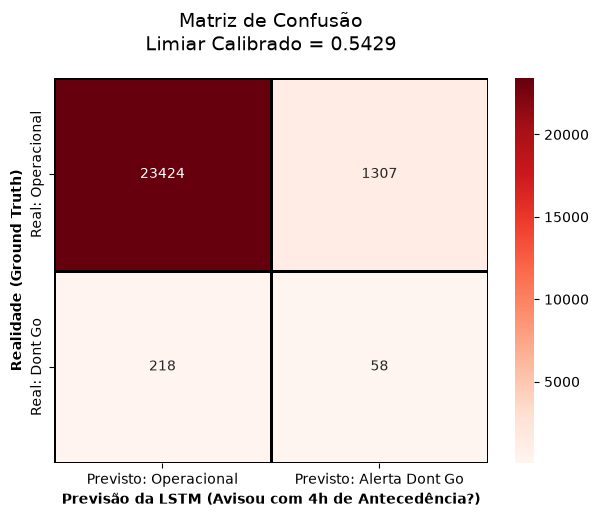

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

print("--- Otimização do Limiar (Threshold) ---")
# 1. Gerar as predições probabilísticas
y_pred_prob = model.predict(X_test).ravel()

# 2. Utilizar a curva de Precision-Recall para achar o ponto de maior eficiência
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Calculando o F1-Score para todos os limiares testados
# Adicionado epsilon (1e-10) para evitar erro matemático de divisão por zero
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Localiza o índice do maior F1-Score e extrai o limiar ideal
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Melhor Threshold Matemático: {best_threshold:.4f}")
print(f"F1-Score Esperado: {best_f1:.4f}")
print(f"Recall Esperado: {recalls[best_idx]:.4f}")
print(f"Precisão Esperada: {precisions[best_idx]:.4f}\n")

# Se desejar um threshold focado puramente em capturar falhas (Recall), 
# você pode baixar esse valor manualmente. Vamos usar o ótimo do F1:
threshold_final = best_threshold

# Aplica o novo threshold
y_pred = (y_pred_prob >= threshold_final).astype(int)

# 3. Exibir o relatório focado na Classe 1
print("--- Relatório de Classificação Final ---")
print(classification_report(y_test, y_pred, target_names=['Classe 0 (Operacional)', 'Classe 1 (Alerta Dont Go)']))

# 4. Plotar a Matriz de Confusão para Cenários Raros
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', linewidths=1, linecolor='black',
            xticklabels=['Previsto: Operacional', 'Previsto: Alerta Dont Go'], 
            yticklabels=['Real: Operacional', 'Real: Dont Go'])
plt.ylabel('Realidade (Ground Truth)', fontweight='bold')
plt.xlabel('Previsão da LSTM (Avisou com 4h de Antecedência?)', fontweight='bold')
plt.title(f'Matriz de Confusão\nLimiar Calibrado = {threshold_final:.4f}', pad=20, fontsize=14)
import os
os.makedirs('../resultados', exist_ok=True)
plt.savefig(f'../resultados/{mes_escolhido}_matriz_confusao.png', bbox_inches='tight', dpi=300)
plt.savefig(f'../resultados/{mes_escolhido}_matriz_confusao.svg', bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Calcular as métricas globais e por classe utilizando o threshold calibrado
# (Substitua y_test e y_pred pelas suas variáveis de teste correspondentes)
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)

# 2. Estruturar as métricas em um dicionário organizado
metricas_dict = {
    'Metrica': ['Acurácia (Global)', 'Precisão (Classe 0)', 'Precisão (Classe 1)', 
                'Recall (Classe 0)', 'Recall (Classe 1)', 'F1-Score (Classe 0)', 'F1-Score (Classe 1)'],
    'Valor': [acc, precision[0], precision[1], recall[0], recall[1], f1[0], f1[1]]
}

# 3. Converter para DataFrame
df_metricas = pd.DataFrame(metricas_dict)

# 4. Salvar na pasta de resultados organizada por mês
pasta_resultados = os.path.join("..", "resultados", mes_escolhido)
os.makedirs(pasta_resultados, exist_ok=True)
plt.savefig(os.path.join(pasta_resultados, f"{mes_escolhido}_matriz_confusao.png"))
# Define o caminho definitivo e exporta o CSV
caminho_salvamento = os.path.join(pasta_resultados, f'{mes_escolhido}_metricas.csv')
df_metricas.to_csv(caminho_salvamento, index=False, encoding='utf-8')

Métricas salvas com sucesso em: ../resultados/jun/jun_metricas.csv
